In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

In [45]:
df = pd.read_csv("../data/processed/soil_pixels_western.csv")
print(df.shape)
df.head()


(3422, 47)


,lon,lat,bd_0-5cm,bd_15-30cm,bd_30-60cm,bd_5-15cm,bd_60-100cm,cec_0-5cm,cec_15-30cm,cec_30-60cm,...,vmc15_0-5cm,vmc15_15-30cm,vmc15_30-60cm,vmc15_5-15cm,vmc15_60-100cm,vmc33_0-5cm,vmc33_15-30cm,vmc33_30-60cm,vmc33_5-15cm,vmc33_60-100cm
0,80.125184,7.323213,1.557927,1.442331,1.439978,1.415508,1.345131,15.267301,16.852371,15.398573,...,0.136998,0.124837,0.130485,0.133131,0.115818,0.195194,0.176813,0.185719,0.189695,0.158228
1,80.134612,7.323213,1.558571,1.440546,1.438355,1.412790,1.345062,15.265265,16.851543,15.398051,...,0.138358,0.125894,0.130853,0.134477,0.116135,0.197316,0.178222,0.186291,0.191714,0.158815
2,80.002622,7.313786,1.543519,1.542667,1.551212,1.527530,1.348263,15.189331,16.596306,14.792064,...,0.112024,0.105075,0.111875,0.109097,0.105837,0.158121,0.150447,0.156935,0.155038,0.137779
3,80.012050,7.313786,1.543147,1.543052,1.551626,1.527253,1.348302,15.187772,16.595743,14.791530,...,0.113405,0.106234,0.112188,0.110480,0.106229,0.159969,0.151812,0.157299,0.156828,0.138326
4,80.021478,7.313786,1.542923,1.543448,1.552039,1.527009,1.348340,15.186189,16.595175,14.790990,...,0.114780,0.107385,0.112495,0.111856,0.106619,0.161818,0.153168,0.157660,0.158620,0.138870


In [46]:
depths = ["0-5cm", "5-15cm", "15-30cm"]
thickness_cm = [5, 10, 15]
thickness_mm = [t * 10 for t in thickness_cm]

fc_cols = [f"vmc33_{d}" for d in depths]
wp_cols = [f"vmc15_{d}" for d in depths]

awc_layers = []
for i in range(len(depths)):
    awc = (df[fc_cols[i]] - df[wp_cols[i]]) * thickness_mm[i]
    awc_layers.append(awc)

df["awc"] = sum(awc_layers)

In [47]:
def weighted_avg(df, prop, depths, weights):
    cols = [f"{prop}_{d}" for d in depths]
    values = np.vstack([df[c] for c in cols])
    return np.average(values, axis=0, weights=weights)

In [48]:
df["organic_carbon"] = weighted_avg(df, "oc", depths, thickness_cm)
df["cec"] = weighted_avg(df, "cec", depths, thickness_cm)
df["ph"] = weighted_avg(df, "ph", depths, thickness_cm)
df["bulk_density"] = weighted_avg(df, "bd", depths, thickness_cm)

df["clay_pct"] = weighted_avg(df, "clay", depths, thickness_cm)
df["sand_pct"] = weighted_avg(df, "sand", depths, thickness_cm)
df["silt_pct"] = 100 - df["clay_pct"] - df["sand_pct"]

In [49]:
clay_high = df["clay_pct"].quantile(0.75)
sand_high = df["sand_pct"].quantile(0.75)   

oc_rich = df["organic_carbon"].quantile(0.66)
bd_low  = df["bulk_density"].quantile(0.33)     

def classify_texture(row):
    clay = row['clay_pct']
    sand = row['sand_pct']
    oc = row['organic_carbon']
    bd = row['bulk_density']
    
    if clay >= clay_high:
        return "Clay loam"
    elif sand >= sand_high:
        return "Sandy loam"
    else:
        is_rich = oc >= oc_rich
        is_well_drained = bd <= bd_low
        
        if is_rich and is_well_drained:
            return "Rich, well-drained loam"
        elif is_well_drained:
            return "Well drained loam"
        elif is_rich:
            return "Rich loam"
        else:
            return "Loam"

df["texture_class"] = df.apply(classify_texture, axis=1)

In [50]:
df[[
    "awc", "organic_carbon", "cec", "ph", "bulk_density"
]].describe().round(2)


,awc,organic_carbon,cec,ph,bulk_density
count,3422.00,3422.00,3422.00,3422.00,3422.00
mean,14.00,3.40,14.68,5.03,1.30
std,1.63,0.60,4.50,0.19,0.10
min,10.20,1.86,7.37,4.71,1.15
25%,12.54,3.05,8.94,4.89,1.23
50%,14.25,3.17,17.02,4.97,1.27
75%,15.13,3.86,18.49,5.15,1.35
max,17.50,4.92,21.05,5.54,1.54


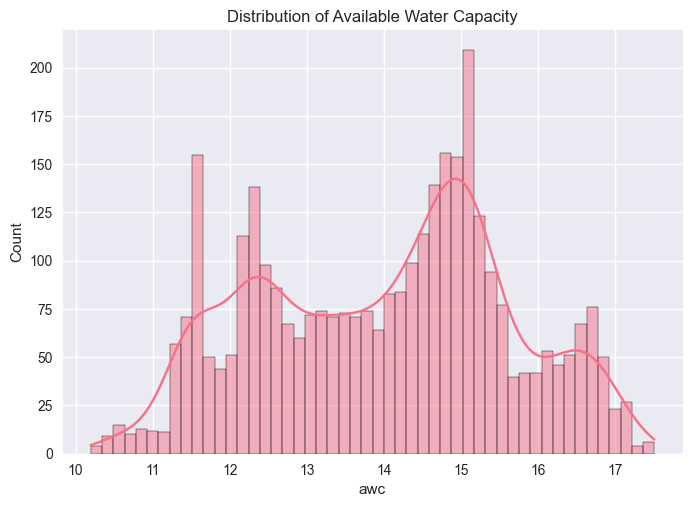

In [51]:
sns.histplot(df["awc"], bins=50, kde=True)
plt.title("Distribution of Available Water Capacity")
plt.show()

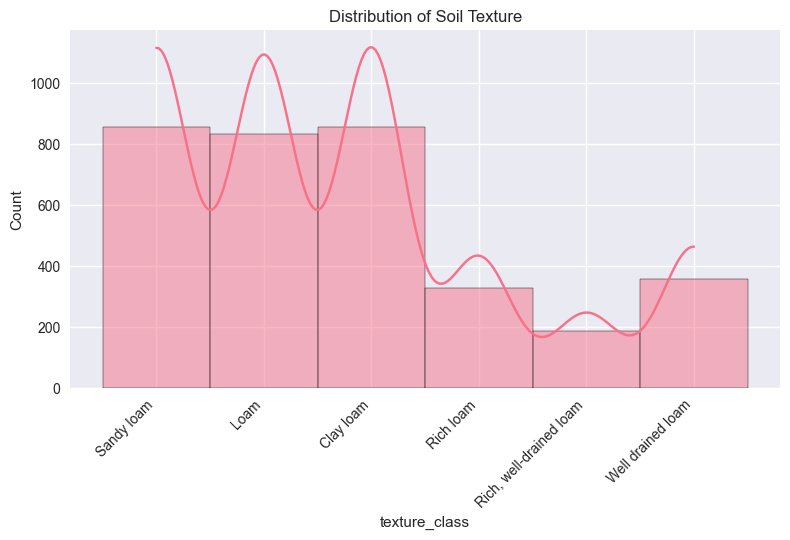

In [55]:
sns.histplot(df["texture_class"], bins=50, kde=True)
plt.xticks(rotation=45, ha='right')
plt.title("Distribution of Soil Texture")
plt.tight_layout()
plt.show()

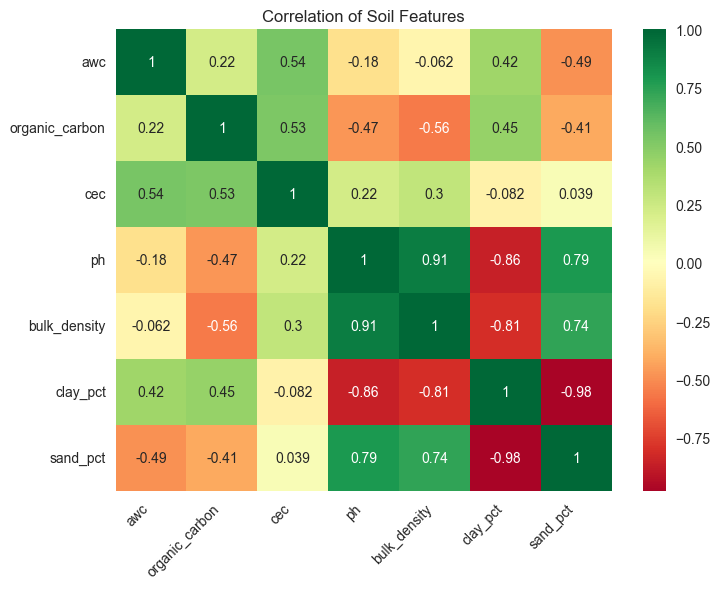

In [73]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[["awc","organic_carbon","cec","ph","bulk_density", "clay_pct", "sand_pct"]].corr(),
    annot=True, cmap="RdYlGn", center=0
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Correlation of Soil Features")
plt.show()


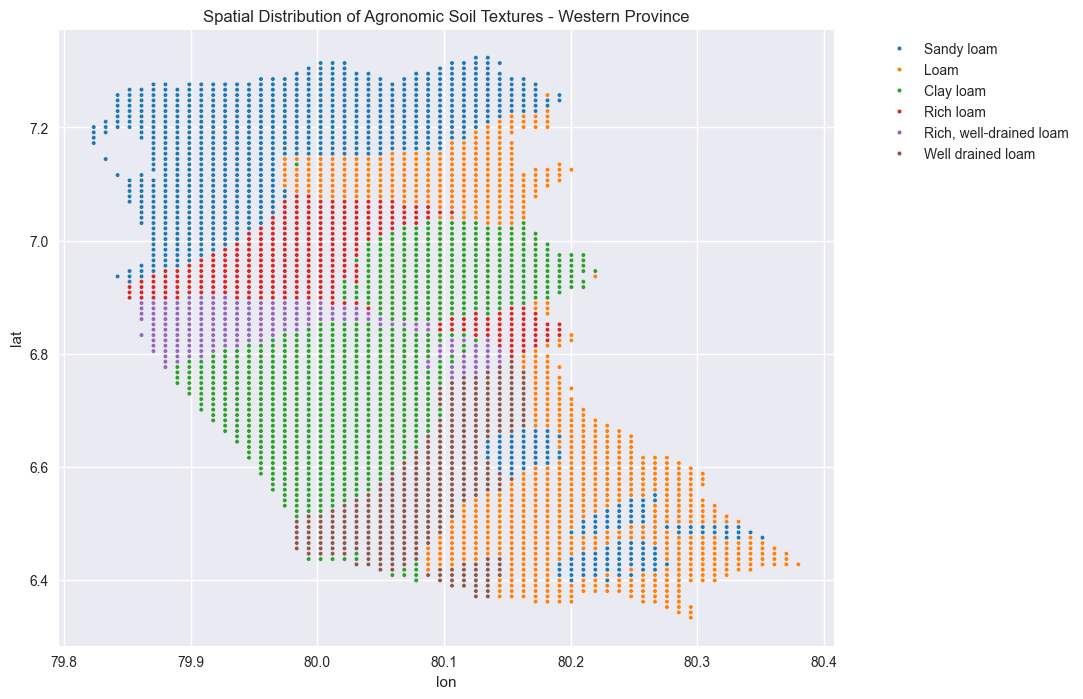

In [59]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x="lon", y="lat", hue="texture_class", palette="tab10", s=10)
plt.title("Spatial Distribution of Agronomic Soil Textures - Western Province")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [63]:
CLUSTER_FEATURES = [
    "awc",
    "organic_carbon",
    "cec",
    "ph",
    "bulk_density",
    "clay_pct",
    "sand_pct"
]


In [64]:
df_final = df[["lon", "lat"] + CLUSTER_FEATURES + ["texture_class"]]
df_final.to_csv("../outputs/soil_features_final.csv", index=False)
